In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Global chart style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------------------------------------
# LOAD THE CSV  ← update path if your file is in a subfolder
# -----------------------------------------------------------
df = pd.read_csv('Sample-Superstore.csv', encoding='latin-1')

# Clean column names: remove spaces and hyphens
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]

# Parse date columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'])

print("✅ Data loaded successfully!")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\n📋 Column names:")
print(df.columns.tolist())

✅ Data loaded successfully!
   Rows: 9,994  |  Columns: 21

📋 Column names:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:

print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)

# Shape
print(f"\n📐 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Null values
print("\n🔍 NULL VALUES PER COLUMN:")
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("   ✅ No nulls found — dataset is clean!")
else:
    print(null_counts[null_counts > 0])

# Duplicates
dupes = df.duplicated(subset=['Order_ID','Product_ID']).sum()
print(f"\n📋 Duplicate (Order+Product) pairs: {dupes}")

# Date range
print(f"\n📅 Order Date range:")
print(f"   From: {df['Order_Date'].min().strftime('%d %b %Y')}")
print(f"   To:   {df['Order_Date'].max().strftime('%d %b %Y')}")
print(f"   Years covered: {sorted(df['Order_Date'].dt.year.unique())}")

# Categories
print(f"\n🏷️  Categories ({df['Category'].nunique()}):")
for cat in df['Category'].unique():
    subcats = df[df['Category'] == cat]['Sub_Category'].unique()
    print(f"   {cat}: {', '.join(subcats)}")

# Key metrics overview
print(f"\n💰 Key Metrics:")
print(f"   Total Sales:    ${df['Sales'].sum():>12,.2f}")
print(f"   Total Profit:   ${df['Profit'].sum():>12,.2f}")
print(f"   Overall Margin: {df['Profit'].sum()/df['Sales'].sum()*100:.2f}%")
print(f"   Avg Order Size: ${df['Sales'].mean():>12,.2f}")
print(f"   Avg Discount:   {df['Discount'].mean()*100:.1f}%")

  DATA QUALITY REPORT

📐 Dataset shape: 9,994 rows × 21 columns

🔍 NULL VALUES PER COLUMN:
   ✅ No nulls found — dataset is clean!

📋 Duplicate (Order+Product) pairs: 8

📅 Order Date range:
   From: 03 Jan 2014
   To:   30 Dec 2017
   Years covered: [2014, 2015, 2016, 2017]

🏷️  Categories (3):
   Furniture: Bookcases, Chairs, Tables, Furnishings
   Office Supplies: Labels, Storage, Art, Binders, Appliances, Paper, Envelopes, Fasteners, Supplies
   Technology: Phones, Accessories, Machines, Copiers

💰 Key Metrics:
   Total Sales:    $2,297,200.86
   Total Profit:   $  286,397.02
   Overall Margin: 12.47%
   Avg Order Size: $      229.86
   Avg Discount:   15.6%


In [6]:

# 1. Profit Margin per transaction (ratio)
df['Profit_Margin'] = df['Profit'] / df['Sales']

# 2. Profit Margin as percentage
df['Profit_Margin_Pct'] = df['Profit_Margin'] * 100

# 3. Lead time: how many days from order to ship
df['Lead_Time_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# 4. Inventory risk score: high discount + low quantity = slow-mover risk
#    Higher score = higher risk of being overstocked / unprofitable
df['Inventory_Score'] = df['Discount'] / (df['Quantity'] + 1)

# 5. Time-based columns for seasonal analysis
df['Year']         = df['Order_Date'].dt.year
df['Month_Num']    = df['Order_Date'].dt.month
df['Month_Name']   = df['Order_Date'].dt.strftime('%b')   # Jan, Feb...
df['Quarter']      = df['Order_Date'].dt.quarter
df['Quarter_Label']= 'Q' + df['Quarter'].astype(str)
df['Year_Month']   = df['Order_Date'].dt.to_period('M').astype(str)

# 6. Discount bucket — groups discounts into bands
df['Discount_Bucket'] = pd.cut(
    df['Discount'],
    bins  = [-0.01, 0.0, 0.10, 0.20, 0.30, 1.0],
    labels= ['0%', '1–10%', '11–20%', '21–30%', '30%+']
)

# 7. Revenue per unit (for inventory turnover proxy)
df['Revenue_Per_Unit'] = df['Sales'] / df['Quantity']

# ------- VERIFY -------
print("✅ New columns created:")
new_cols = ['Profit_Margin','Profit_Margin_Pct','Lead_Time_Days',
            'Inventory_Score','Year','Month_Num','Month_Name',
            'Quarter','Quarter_Label','Year_Month','Discount_Bucket',
            'Revenue_Per_Unit']
for col in new_cols:
    sample = df[col].iloc[0]
    print(f"   {col:22s}  →  sample value: {sample}")

✅ New columns created:
   Profit_Margin           →  sample value: 0.16000000000000003
   Profit_Margin_Pct       →  sample value: 16.000000000000004
   Lead_Time_Days          →  sample value: 3
   Inventory_Score         →  sample value: 0.0
   Year                    →  sample value: 2016
   Month_Num               →  sample value: 11
   Month_Name              →  sample value: Nov
   Quarter                 →  sample value: 4
   Quarter_Label           →  sample value: Q4
   Year_Month              →  sample value: 2016-11
   Discount_Bucket         →  sample value: 0%
   Revenue_Per_Unit        →  sample value: 130.98


📊 PROFIT MARGIN BY CATEGORY
─────────────────────────────────────────────────────────────────
Category                    Sales       Profit  Margin%  Avg Disc%
─────────────────────────────────────────────────────────────────
Technology           $    836,154 $    145,455    17.4%      13.2%
Office Supplies      $    719,047 $    122,491    17.0%      15.7%
Furniture            $    742,000 $     18,451     2.5%      17.4%


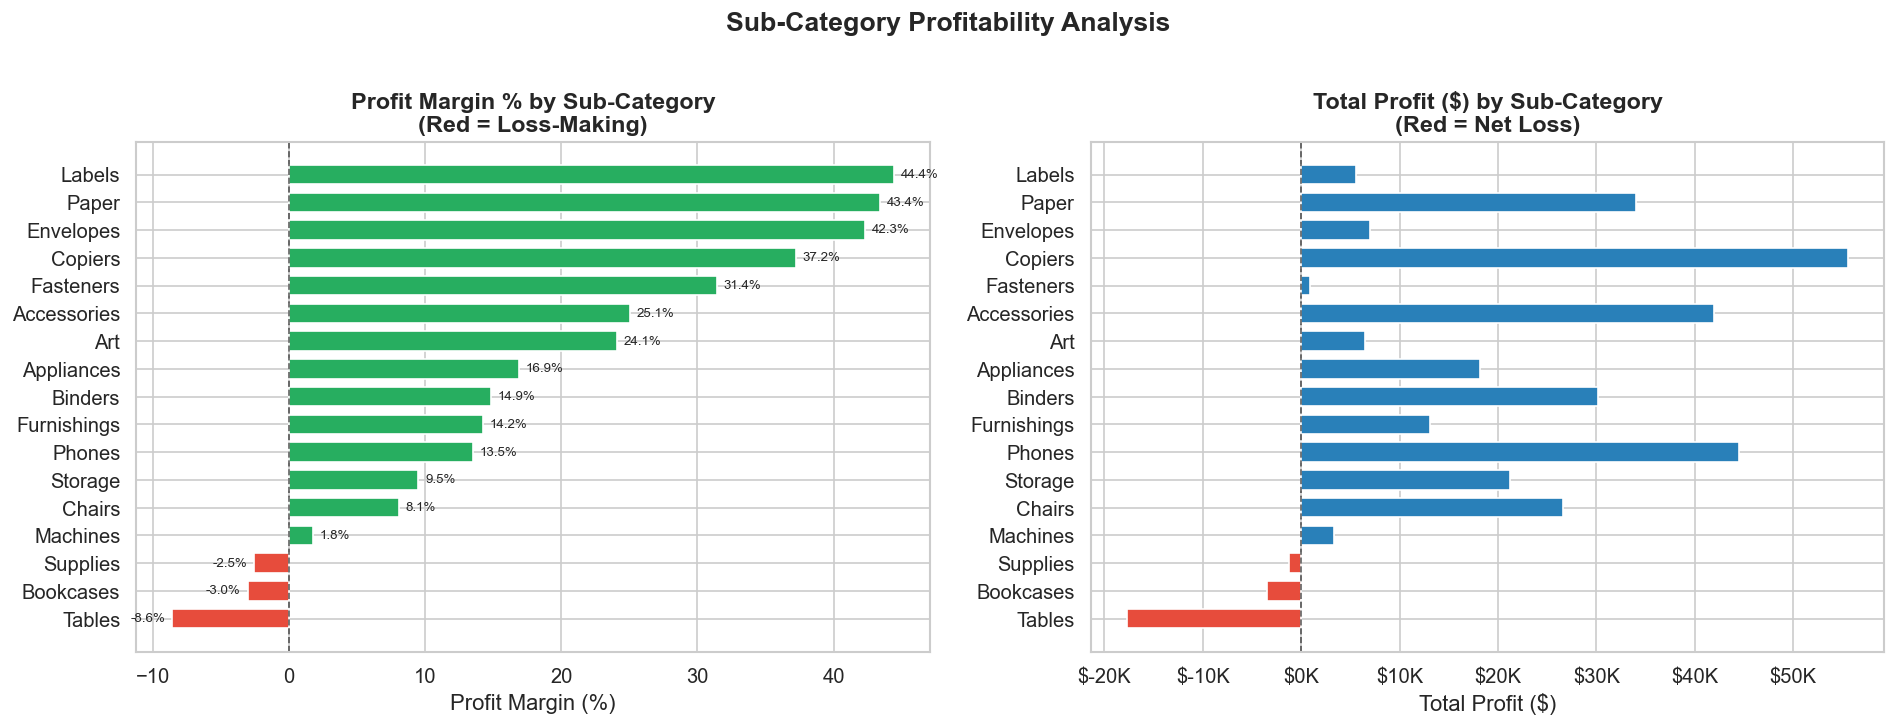


🔴 LOSS-MAKING SUB-CATEGORIES (3 found):
───────────────────────────────────────────────────────
  Tables          Loss: $   -17,725   Margin: -8.6%    Avg Disc: 26%
  Bookcases       Loss: $    -3,473   Margin: -3.0%    Avg Disc: 21%
  Supplies        Loss: $    -1,189   Margin: -2.5%    Avg Disc: 8%


In [7]:

cat_summary = df.groupby('Category').agg(
    Total_Sales   = ('Sales',   'sum'),
    Total_Profit  = ('Profit',  'sum'),
    Total_Units   = ('Quantity','sum'),
    Avg_Discount  = ('Discount','mean'),
    Num_Orders    = ('Order_ID','count')
).reset_index()

cat_summary['Margin_Pct'] = (cat_summary['Total_Profit'] /
                              cat_summary['Total_Sales'] * 100).round(2)

print("📊 PROFIT MARGIN BY CATEGORY")
print("─" * 65)
print(f"{'Category':<20} {'Sales':>12} {'Profit':>12} {'Margin%':>8} {'Avg Disc%':>10}")
print("─" * 65)
for _, r in cat_summary.sort_values('Margin_Pct', ascending=False).iterrows():
    print(f"{r['Category']:<20} ${r['Total_Sales']:>11,.0f} "
          f"${r['Total_Profit']:>11,.0f} {r['Margin_Pct']:>7.1f}% "
          f"{r['Avg_Discount']*100:>9.1f}%")

# ── 4B. Sub-Category-level summary ─────────────────────────
sub_summary = df.groupby(['Category','Sub_Category']).agg(
    Total_Sales   = ('Sales',   'sum'),
    Total_Profit  = ('Profit',  'sum'),
    Total_Units   = ('Quantity','sum'),
    Avg_Discount  = ('Discount','mean')
).reset_index()

sub_summary['Margin_Pct'] = (sub_summary['Total_Profit'] /
                              sub_summary['Total_Sales'] * 100).round(2)
sub_summary = sub_summary.sort_values('Margin_Pct')

# ── 4C. CHART ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Sub-category horizontal bar
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in sub_summary['Margin_Pct']]
bars = axes[0].barh(sub_summary['Sub_Category'],
                    sub_summary['Margin_Pct'],
                    color=colors, edgecolor='white', height=0.7)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Profit Margin (%)')
axes[0].set_title('Profit Margin % by Sub-Category\n(Red = Loss-Making)')

# Value labels on bars
for bar, val in zip(bars, sub_summary['Margin_Pct']):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', ha=ha, fontsize=8)

# Right: Total profit by sub-category
profit_colors = ['#e74c3c' if x < 0 else '#2980b9'
                 for x in sub_summary['Total_Profit']]
axes[1].barh(sub_summary['Sub_Category'],
             sub_summary['Total_Profit'],
             color=profit_colors, edgecolor='white', height=0.7)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_title('Total Profit ($) by Sub-Category\n(Red = Net Loss)')

plt.suptitle('Sub-Category Profitability Analysis', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_01_subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4D. Print loss-makers ───────────────────────────────────
loss_makers = sub_summary[sub_summary['Total_Profit'] < 0]
print(f"\n🔴 LOSS-MAKING SUB-CATEGORIES ({len(loss_makers)} found):")
print("─" * 55)
for _, r in loss_makers.iterrows():
    print(f"  {r['Sub_Category']:<15} Loss: ${r['Total_Profit']:>10,.0f} "
          f"  Margin: {r['Margin_Pct']:.1f}%  "
          f"  Avg Disc: {r['Avg_Discount']*100:.0f}%")

Rows after removing outliers: 9,567 (removed 427 outliers)

📈 PEARSON CORRELATION RESULTS
────────────────────────────────────────────────────────────
Variable                   r value     p-value   Significant?
────────────────────────────────────────────────────────────
Inventory Score            -0.7408    0.000000          ✅ Yes
Discount                   -0.8522    0.000000          ✅ Yes
Quantity                   -0.0056    0.587222           ❌ No

📌 Interpretation:
   Discount vs Profit Margin: r=-0.852
   → Strong NEGATIVE correlation: higher discount = lower profit margin


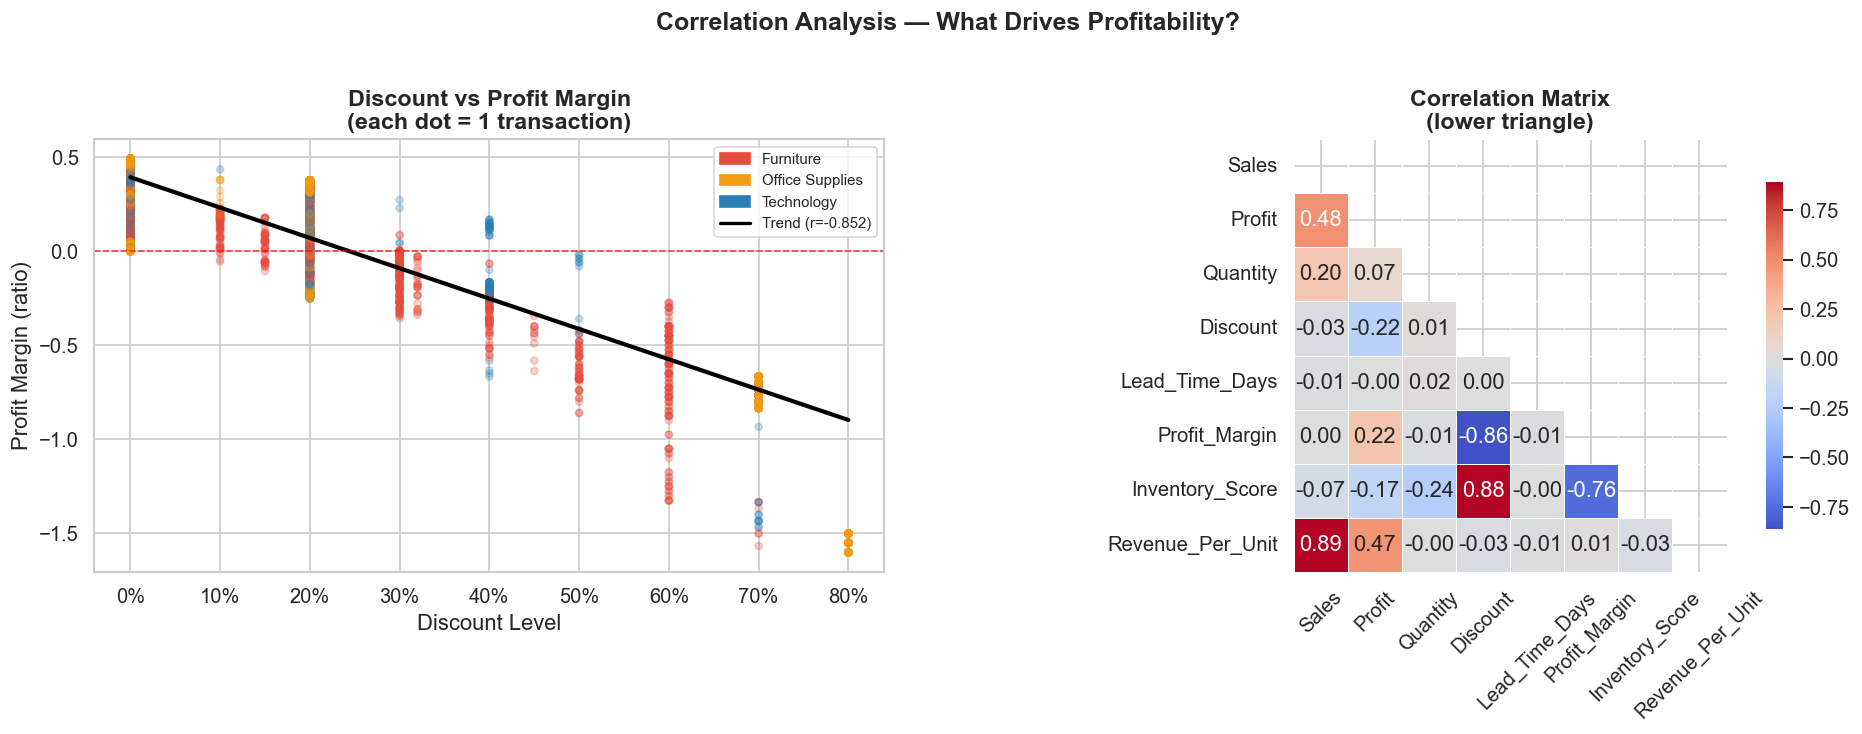

In [8]:

q_low  = df['Profit_Margin'].quantile(0.02)
q_high = df['Profit_Margin'].quantile(0.98)
df_clean = df[(df['Profit_Margin'] > q_low) & (df['Profit_Margin'] < q_high)].copy()

print(f"Rows after removing outliers: {len(df_clean):,} (removed {len(df)-len(df_clean)} outliers)")

# ── 5A. Pearson Correlation ─────────────────────────────────
corr_inv, pval_inv = stats.pearsonr(df_clean['Inventory_Score'],
                                     df_clean['Profit_Margin'])
corr_disc, pval_disc = stats.pearsonr(df_clean['Discount'],
                                       df_clean['Profit_Margin'])
corr_qty, pval_qty   = stats.pearsonr(df_clean['Quantity'],
                                       df_clean['Profit_Margin'])

print("\n📈 PEARSON CORRELATION RESULTS")
print("─" * 60)
print(f"{'Variable':<25} {'r value':>8}  {'p-value':>10}  {'Significant?':>13}")
print("─" * 60)
for name, r, p in [
    ('Inventory Score',  corr_inv,  pval_inv),
    ('Discount',         corr_disc, pval_disc),
    ('Quantity',         corr_qty,  pval_qty)
]:
    sig = '✅ Yes' if p < 0.05 else '❌ No'
    print(f"{name:<25} {r:>8.4f}  {p:>10.6f}  {sig:>13}")

print("\n📌 Interpretation:")
print(f"   Discount vs Profit Margin: r={corr_disc:.3f}")
if corr_disc < -0.3:
    print("   → Strong NEGATIVE correlation: higher discount = lower profit margin")
elif corr_disc < 0:
    print("   → Moderate negative correlation: discounts do hurt margins")

# ── 5B. Full Correlation Matrix ─────────────────────────────
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount',
            'Lead_Time_Days', 'Profit_Margin', 'Inventory_Score',
            'Revenue_Per_Unit']
corr_matrix = df[num_cols].corr().round(2)

# ── 5C. CHARTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter — Discount vs Profit Margin
scatter_colors = df_clean['Category'].map({
    'Furniture':      '#e74c3c',
    'Office Supplies':'#f39c12',
    'Technology':     '#2980b9'
})
axes[0].scatter(df_clean['Discount'], df_clean['Profit_Margin'],
                c=scatter_colors, alpha=0.25, s=18)

# Regression line
m, b = np.polyfit(df_clean['Discount'], df_clean['Profit_Margin'], 1)
x_range = np.linspace(0, df_clean['Discount'].max(), 100)
axes[0].plot(x_range, m*x_range + b, color='black',
             linewidth=2.5, label=f'Trend (r={corr_disc:.3f})')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#e74c3c', label='Furniture'),
    Patch(color='#f39c12', label='Office Supplies'),
    Patch(color='#2980b9', label='Technology'),
    plt.Line2D([0],[0], color='black', lw=2, label=f'Trend (r={corr_disc:.3f})')
]
axes[0].legend(handles=legend_handles, fontsize=9)
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Profit Margin (ratio)')
axes[0].set_title('Discount vs Profit Margin\n(each dot = 1 transaction)')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right: Correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            mask=mask, ax=axes[1],
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Matrix\n(lower triangle)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Correlation Analysis — What Drives Profitability?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

📊 PROFIT BY DISCOUNT BUCKET
───────────────────────────────────────────────────────────────────────────
Bucket      Orders   Avg Profit   Total Profit  % Loss Orders
───────────────────────────────────────────────────────────────────────────
0%           4,798   $     66.90   $     320,988           0.0%
1–10%           94   $     96.06   $       9,029           4.3%
11–20%       3,709   $     24.74   $      91,756          14.0%
21–30%         227   $    -45.68   $     -10,369          91.6% ⚠️
30%+         1,166   $   -107.21   $    -125,007          97.8% ⚠️


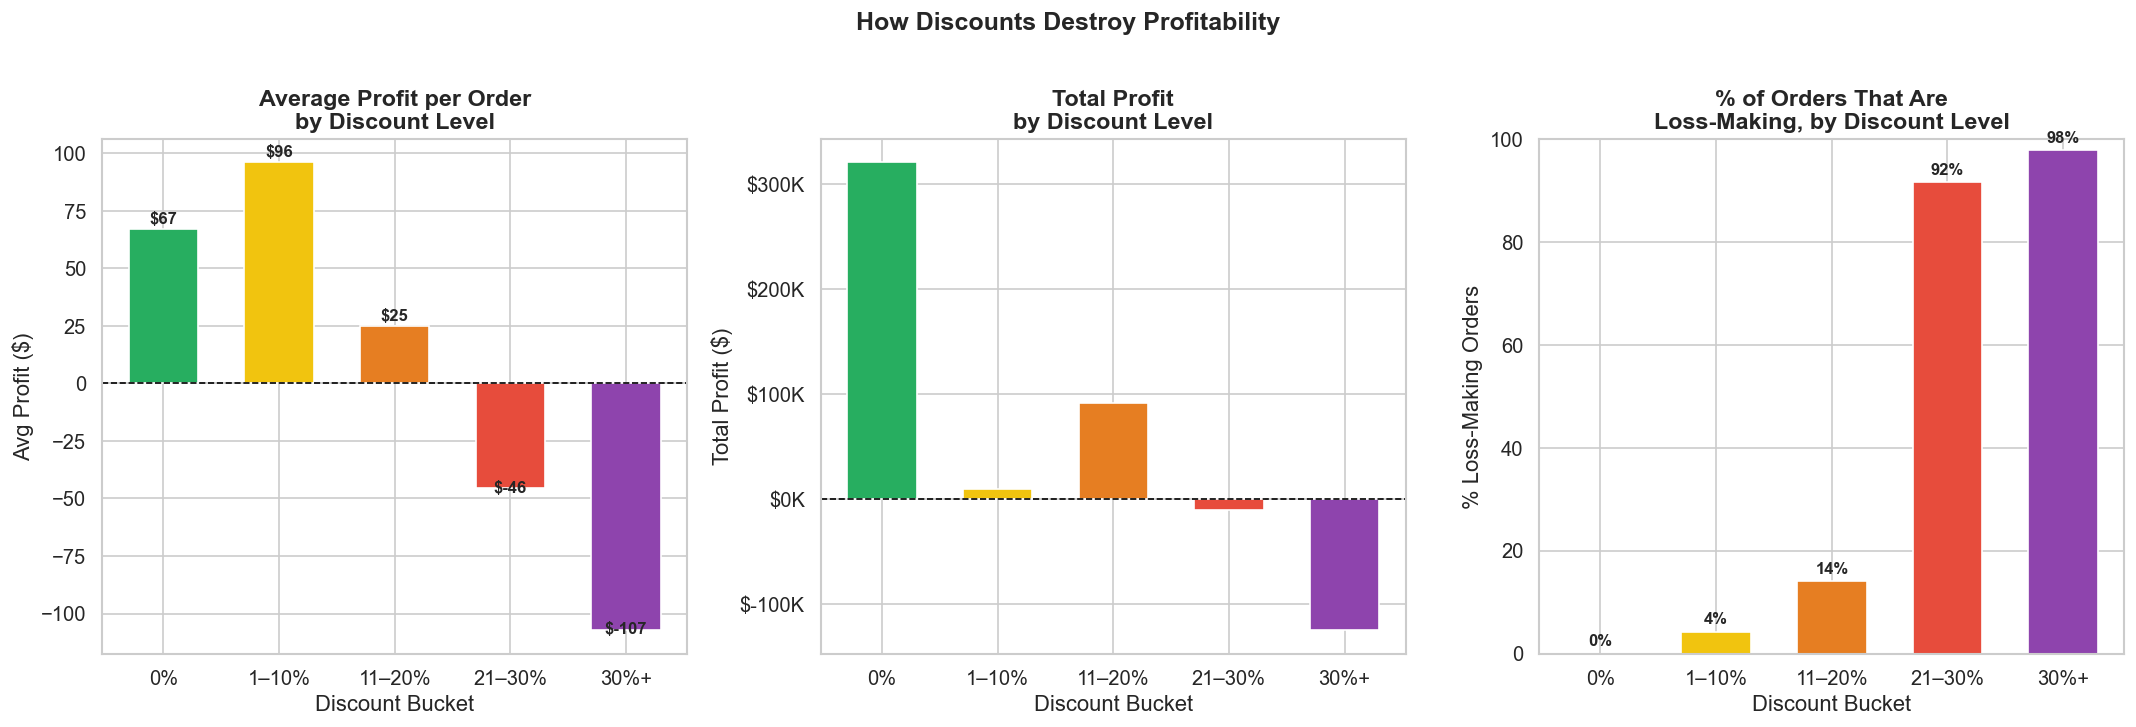


💡 KEY FINDING:
   Orders at 0% discount:   avg profit = $66.90
   Orders at 30%+ discount: avg profit = $-107.21
   Profit drops by $174.11 per order when heavy discounting


In [12]:

disc_summary = df.groupby('Discount_Bucket', observed=True).agg(
    Num_Orders   = ('Profit', 'count'),
    Avg_Profit   = ('Profit', 'mean'),
    Total_Profit = ('Profit', 'sum'),
    Avg_Sales    = ('Sales',  'mean'),
    Pct_Negative = ('Profit', lambda x: (x < 0).mean() * 100)
).reset_index()

print("📊 PROFIT BY DISCOUNT BUCKET")
print("─" * 75)
print(f"{'Bucket':<10} {'Orders':>7} {'Avg Profit':>12} {'Total Profit':>14} "
      f"{'% Loss Orders':>14}")
print("─" * 75)
for _, r in disc_summary.iterrows():
    loss_flag = ' ⚠️' if r['Avg_Profit'] < 0 else ''
    print(f"{str(r['Discount_Bucket']):<10} {r['Num_Orders']:>7,} "
          f"  ${r['Avg_Profit']:>10,.2f} "
          f"  ${r['Total_Profit']:>12,.0f}  "
          f"{r['Pct_Negative']:>12.1f}%{loss_flag}")

# ── 6B. Sub-category breakdown by discount ──────────────────
disc_sub = df.groupby(['Sub_Category', 'Discount_Bucket'],
                       observed=True)['Profit'].mean().reset_index()
disc_sub_pivot = disc_sub.pivot(index='Sub_Category',
                                columns='Discount_Bucket',
                                values='Profit').round(1)

# ── 6C. CHARTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

# Chart 1: Avg Profit per bucket
bars = axes[0].bar(disc_summary['Discount_Bucket'].astype(str),
                   disc_summary['Avg_Profit'],
                   color=palette, edgecolor='white', width=0.6)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Average Profit per Order\nby Discount Level')
axes[0].set_xlabel('Discount Bucket')
axes[0].set_ylabel('Avg Profit ($)')
for bar, val in zip(bars, disc_summary['Avg_Profit']):
    y = val + 1 if val >= 0 else val - 3
    axes[0].text(bar.get_x() + bar.get_width()/2, y,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=10,
                 fontweight='bold')

# Chart 2: Total Profit per bucket
axes[1].bar(disc_summary['Discount_Bucket'].astype(str),
            disc_summary['Total_Profit'],
            color=palette, edgecolor='white', width=0.6)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_title('Total Profit\nby Discount Level')
axes[1].set_xlabel('Discount Bucket')
axes[1].set_ylabel('Total Profit ($)')

# Chart 3: % of orders that are loss-making
bars3 = axes[2].bar(disc_summary['Discount_Bucket'].astype(str),
                    disc_summary['Pct_Negative'],
                    color=palette, edgecolor='white', width=0.6)
axes[2].set_title('% of Orders That Are\nLoss-Making, by Discount Level')
axes[2].set_xlabel('Discount Bucket')
axes[2].set_ylabel('% Loss-Making Orders')
axes[2].set_ylim(0, 100)
for bar, val in zip(bars3, disc_summary['Pct_Negative']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.0f}%',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('How Discounts Destroy Profitability',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_03_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 KEY FINDING:")
zero_avg  = disc_summary[disc_summary['Discount_Bucket']=='0%']['Avg_Profit'].values[0]
high_avg  = disc_summary[disc_summary['Discount_Bucket']=='30%+']['Avg_Profit'].values[0]
print(f"   Orders at 0% discount:   avg profit = ${zero_avg:.2f}")
print(f"   Orders at 30%+ discount: avg profit = ${high_avg:.2f}")
print(f"   Profit drops by ${zero_avg - high_avg:.2f} per order when heavy discounting")

📅 AVERAGE MONTHLY PERFORMANCE (2014–2017)
──────────────────────────────────────────────────
Month     Avg Sales   Avg Profit
──────────────────────────────────────────────────
Jan    $        249 $         24
Feb    $        199 $         34
Mar    $        295 $         41 ← Peak
Apr    $        206 $         17 ← Low
May    $        211 $         30
Jun    $        213 $         30
Jul    $        207 $         19
Aug    $        225 $         31
Sep    $        222 $         27
Oct    $        245 $         39
Nov    $        240 $         24
Dec    $        231 $         31


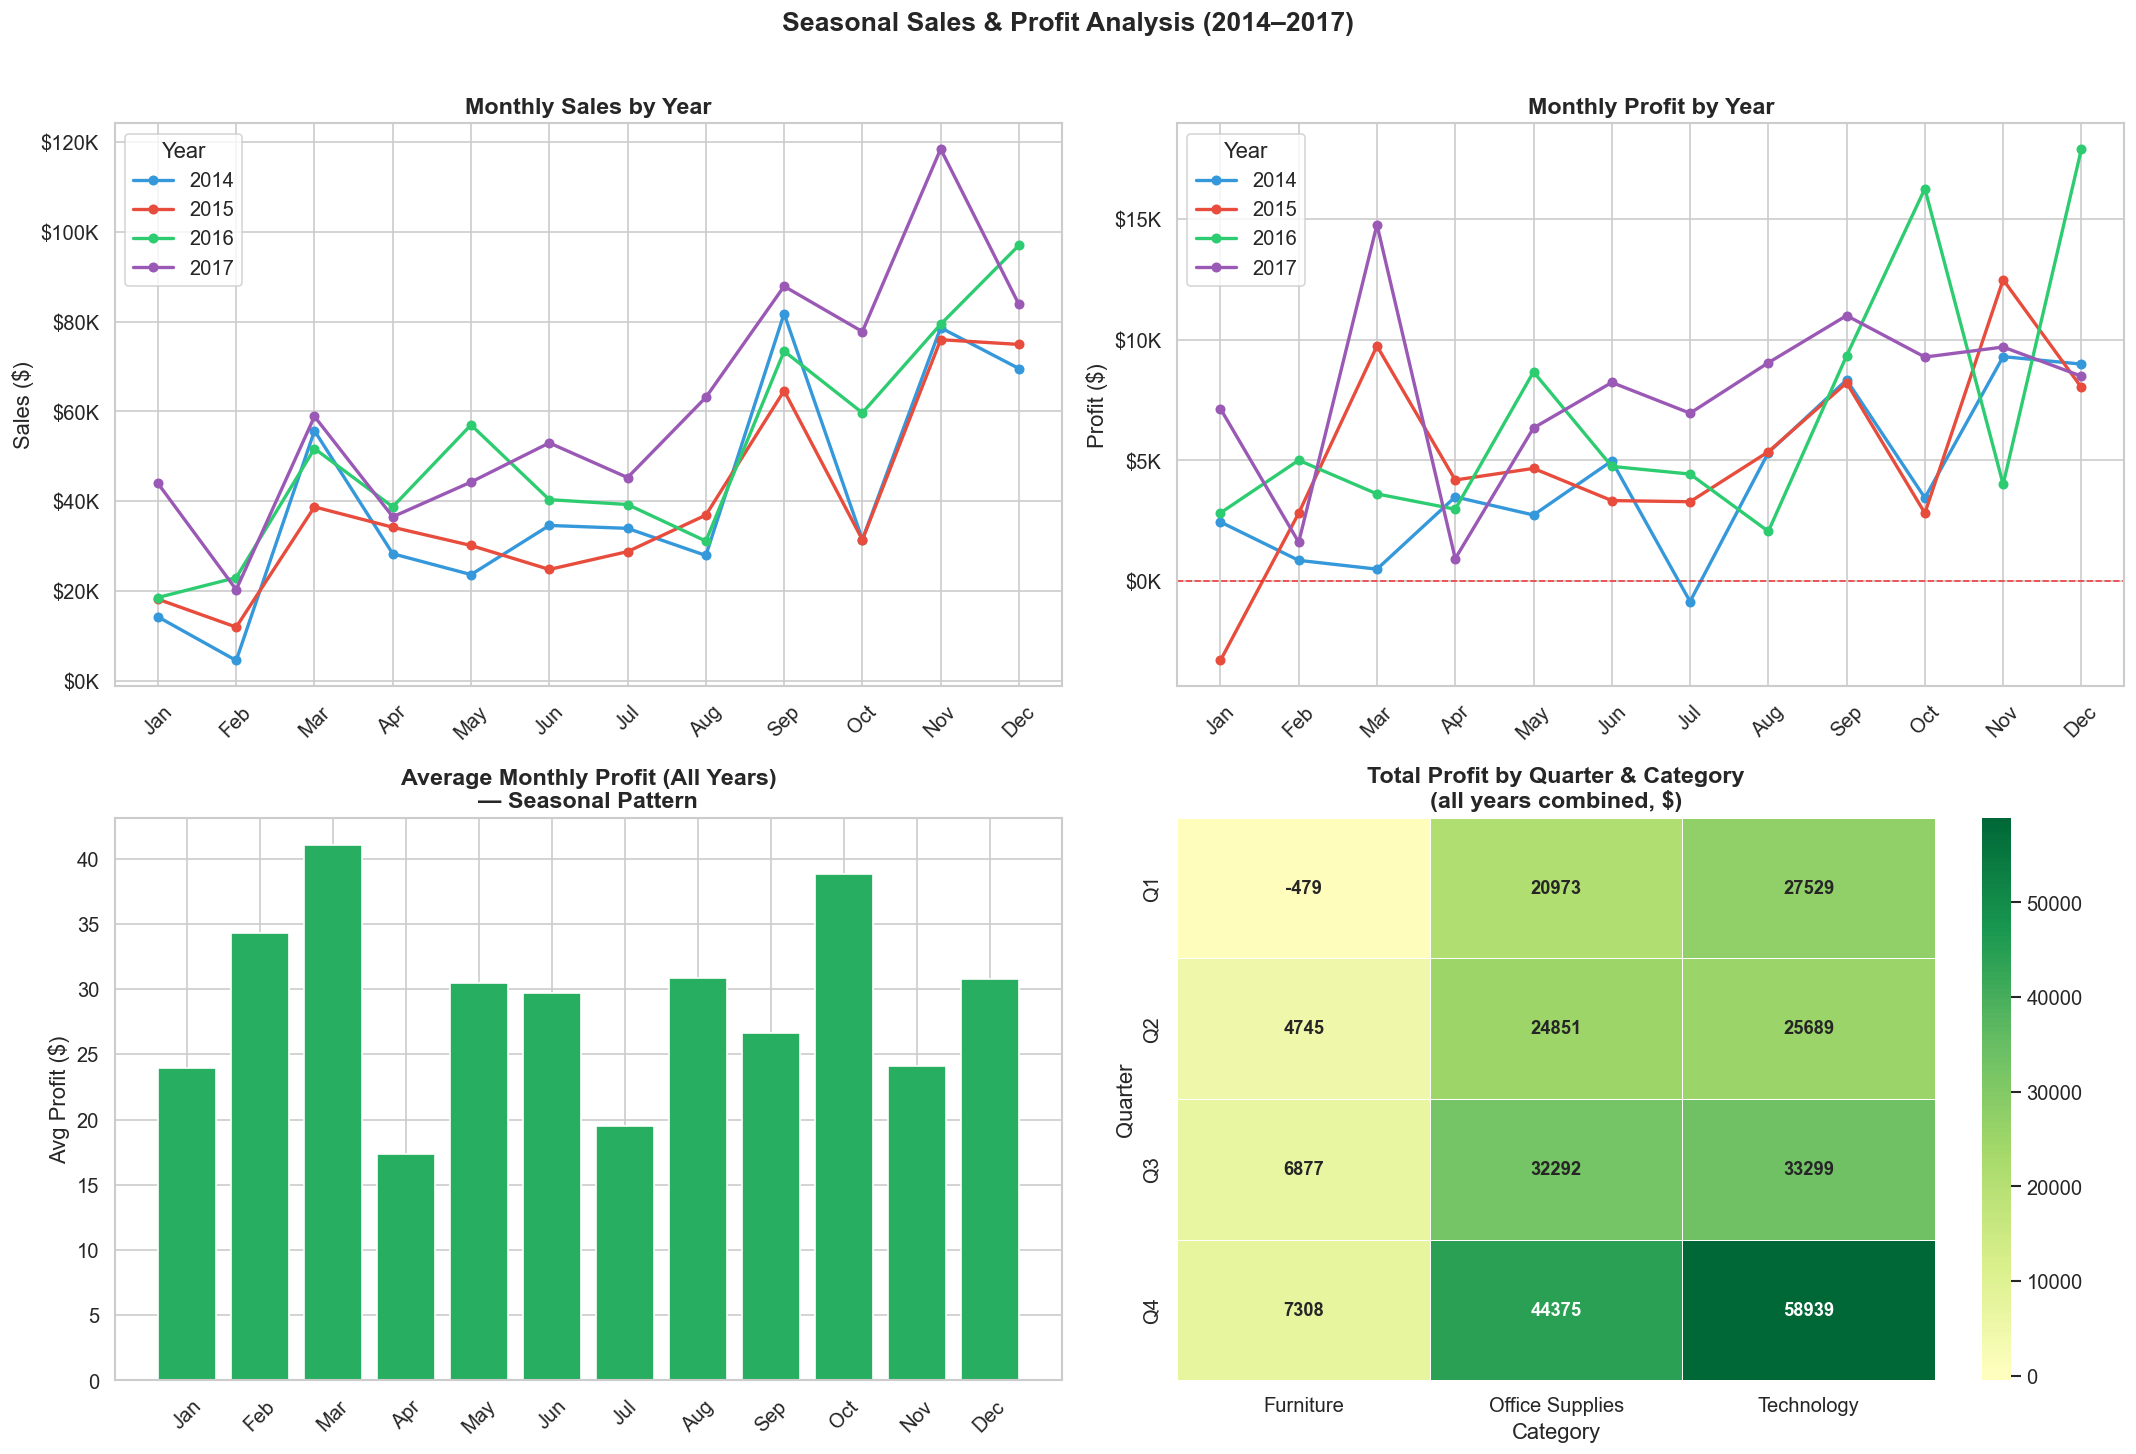

In [14]:

monthly = df.groupby(['Year', 'Month_Num', 'Month_Name']).agg(
    Sales  = ('Sales',    'sum'),
    Profit = ('Profit',   'sum'),
    Orders = ('Order_ID', 'count')
).reset_index().sort_values(['Year', 'Month_Num'])

# ── 7B. Quarterly aggregation ────────────────────────────────
quarterly = df.groupby(['Year', 'Quarter_Label', 'Category']).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()

# Average profit by month (across all years)
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df.groupby('Month_Name').agg(
    Avg_Profit = ('Profit','mean'),
    Avg_Sales  = ('Sales', 'mean')
).reindex(month_order).reset_index()

print("📅 AVERAGE MONTHLY PERFORMANCE (2014–2017)")
print("─" * 50)
print(f"{'Month':<6} {'Avg Sales':>12} {'Avg Profit':>12}")
print("─" * 50)
for _, r in monthly_avg.iterrows():
    flag = ' ← Peak' if r['Avg_Profit'] == monthly_avg['Avg_Profit'].max() else ''
    flag = ' ← Low'  if r['Avg_Profit'] == monthly_avg['Avg_Profit'].min() else flag
    print(f"{r['Month_Name']:<6} ${r['Avg_Sales']:>11,.0f} ${r['Avg_Profit']:>11,.0f}{flag}")

# ── 7C. CHARTS ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
year_colors = {2014: '#3498db', 2015: '#e74c3c',
               2016: '#2ecc71', 2017: '#9b59b6'}

# Chart 1 (top-left): Monthly Sales by Year
for yr in sorted(df['Year'].unique()):
    d = monthly[monthly['Year'] == yr]
    axes[0,0].plot(d['Month_Num'], d['Sales'],
                   marker='o', markersize=5, linewidth=2,
                   label=str(yr), color=year_colors[yr])
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_order, rotation=45)
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0,0].set_title('Monthly Sales by Year')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].legend(title='Year')

# Chart 2 (top-right): Monthly Profit by Year
for yr in sorted(df['Year'].unique()):
    d = monthly[monthly['Year'] == yr]
    axes[0,1].plot(d['Month_Num'], d['Profit'],
                   marker='o', markersize=5, linewidth=2,
                   label=str(yr), color=year_colors[yr])
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_order, rotation=45)
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0,1].set_title('Monthly Profit by Year')
axes[0,1].set_ylabel('Profit ($)')
axes[0,1].legend(title='Year')

# Chart 3 (bottom-left): Avg Profit by Month (seasonality pattern)
bar_colors = ['#e74c3c' if x < 0 else '#27ae60'
              for x in monthly_avg['Avg_Profit']]
axes[1,0].bar(monthly_avg['Month_Name'], monthly_avg['Avg_Profit'],
              color=bar_colors, edgecolor='white')
axes[1,0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1,0].set_title('Average Monthly Profit (All Years)\n— Seasonal Pattern')
axes[1,0].set_ylabel('Avg Profit ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 (bottom-right): Quarterly heatmap by Category
q_order = ['Q1','Q2','Q3','Q4']
pivot = quarterly.groupby(['Quarter_Label','Category'])['Profit'].sum().unstack()
pivot = pivot.reindex(q_order)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            center=0, ax=axes[1,1], linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1,1].set_title('Total Profit by Quarter & Category\n(all years combined, $)')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Quarter')

plt.suptitle('Seasonal Sales & Profit Analysis (2014–2017)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_04_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

🗺️  REGIONAL PERFORMANCE SUMMARY
────────────────────────────────────────────────────────────────────────────────
Region            Sales       Profit  Margin%   Orders  Customers
────────────────────────────────────────────────────────────────────────────────
West       $    725,458 $    108,418    14.9%    3,203        686
East       $    678,781 $     91,523    13.5%    2,848        674
South      $    391,722 $     46,749    11.9%    1,620        512
Central    $    501,240 $     39,706     7.9%    2,323        629

🔴 BOTTOM 5 STATES (Biggest Losses):
         State  Region       Sales      Profit
         Texas Central 170188.0458 -25729.3563
          Ohio    East  78258.1360 -16971.3766
  Pennsylvania    East 116511.9140 -15559.9603
      Illinois Central  80166.1010 -12607.8870
North Carolina   South  55603.1640  -7490.9122

🟢 TOP 5 STATES (Highest Profit):
     State  Region       Sales     Profit
  Virginia   South  70636.7200 18597.9504
  Michigan Central  76269.6140 24463.1

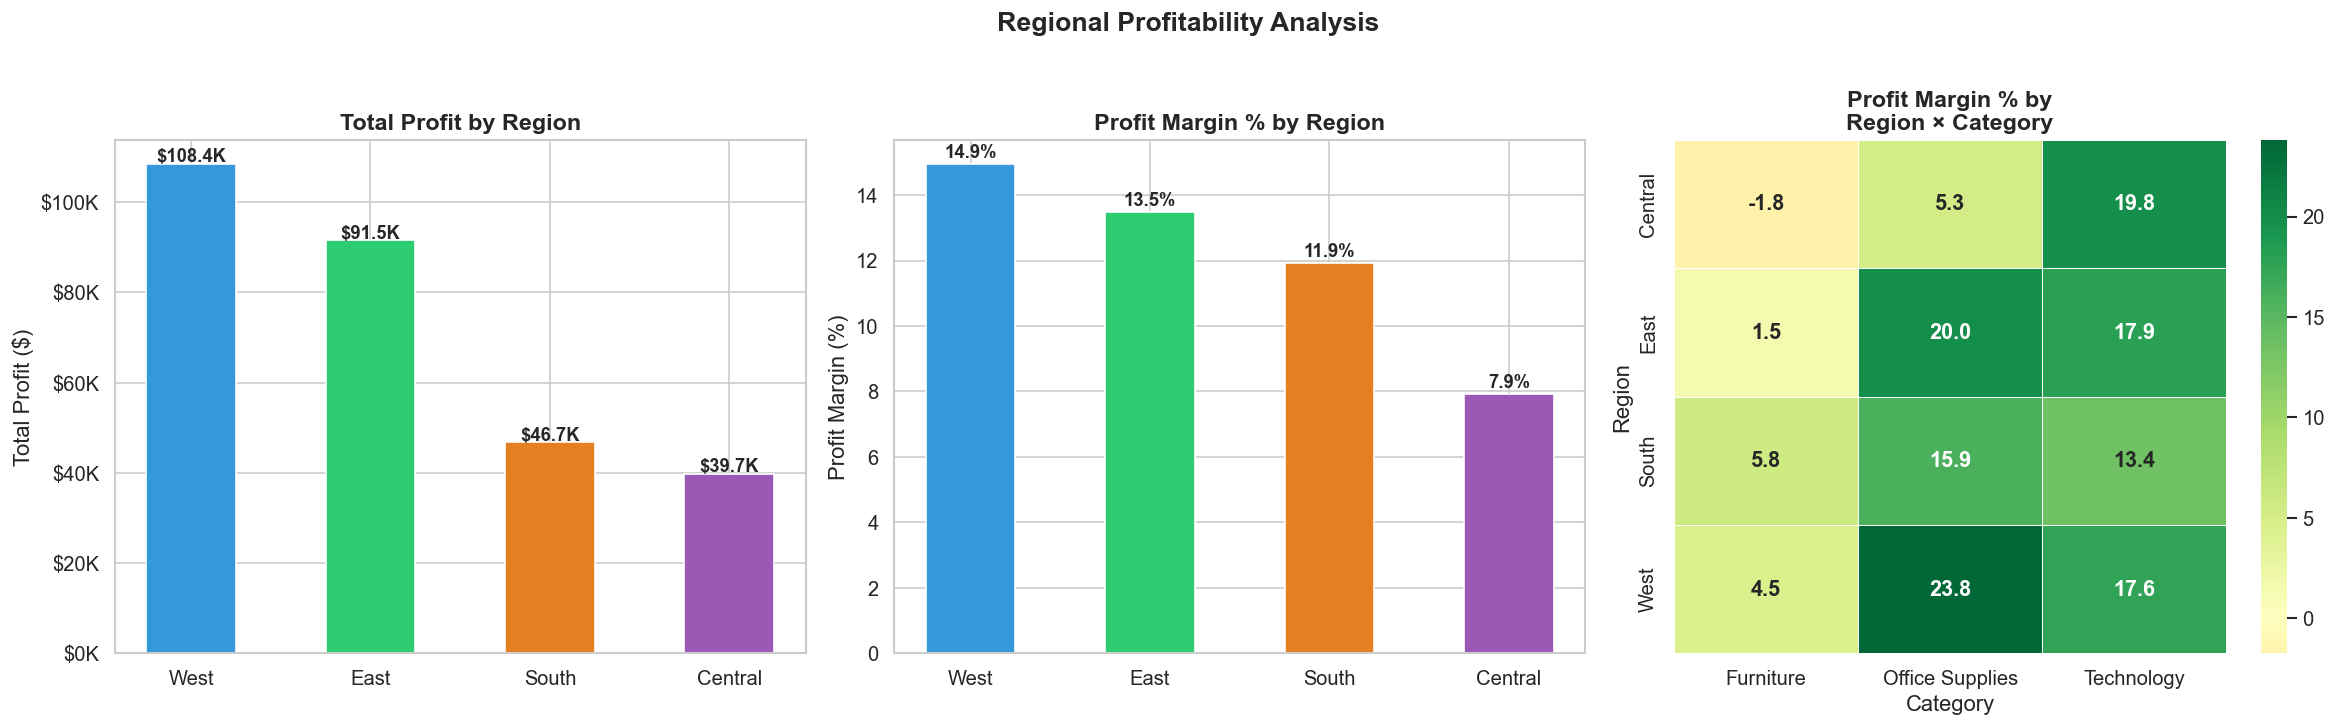

In [15]:

region_summary = df.groupby('Region').agg(
    Total_Sales     = ('Sales',       'sum'),
    Total_Profit    = ('Profit',      'sum'),
    Num_Orders      = ('Order_ID',    'count'),
    Unique_Customers= ('Customer_ID', 'nunique'),
    Avg_Discount    = ('Discount',    'mean')
).reset_index()
region_summary['Margin_Pct'] = (region_summary['Total_Profit'] /
                                 region_summary['Total_Sales'] * 100).round(2)
region_summary = region_summary.sort_values('Margin_Pct', ascending=False)

print("🗺️  REGIONAL PERFORMANCE SUMMARY")
print("─" * 80)
print(f"{'Region':<10} {'Sales':>12} {'Profit':>12} {'Margin%':>8} "
      f"{'Orders':>8} {'Customers':>10}")
print("─" * 80)
for _, r in region_summary.iterrows():
    print(f"{r['Region']:<10} ${r['Total_Sales']:>11,.0f} "
          f"${r['Total_Profit']:>11,.0f} {r['Margin_Pct']:>7.1f}% "
          f"{r['Num_Orders']:>8,} {r['Unique_Customers']:>10,}")

# ── 8B. Region × Category ────────────────────────────────────
region_cat = df.groupby(['Region','Category']).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()
region_cat['Margin_Pct'] = (region_cat['Profit'] /
                             region_cat['Sales'] * 100).round(2)

# ── 8C. State-level (top/bottom 5) ──────────────────────────
state_perf = df.groupby(['State','Region']).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index().sort_values('Profit')

print("\n🔴 BOTTOM 5 STATES (Biggest Losses):")
print(state_perf.head(5)[['State','Region','Sales','Profit']].to_string(index=False))
print("\n🟢 TOP 5 STATES (Highest Profit):")
print(state_perf.tail(5)[['State','Region','Sales','Profit']].to_string(index=False))

# ── 8D. CHARTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Total Profit by Region
region_colors = ['#3498db','#2ecc71','#e67e22','#9b59b6']
bars = axes[0].bar(region_summary['Region'], region_summary['Total_Profit'],
                   color=region_colors, edgecolor='white', width=0.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title('Total Profit by Region')
axes[0].set_ylabel('Total Profit ($)')
for bar, val in zip(bars, region_summary['Total_Profit']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 500, f'${val/1000:.1f}K',
                 ha='center', fontsize=11, fontweight='bold')

# Chart 2: Margin % by Region
axes[1].bar(region_summary['Region'], region_summary['Margin_Pct'],
            color=region_colors, edgecolor='white', width=0.5)
axes[1].set_title('Profit Margin % by Region')
axes[1].set_ylabel('Profit Margin (%)')
for i, (_, r) in enumerate(region_summary.iterrows()):
    axes[1].text(i, r['Margin_Pct'] + 0.2,
                 f"{r['Margin_Pct']:.1f}%",
                 ha='center', fontsize=11, fontweight='bold')

# Chart 3: Heatmap — Region × Category Margin
margin_pivot = region_cat.pivot(index='Region',
                                columns='Category',
                                values='Margin_Pct')
sns.heatmap(margin_pivot, annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, ax=axes[2],
            linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
axes[2].set_title('Profit Margin % by\nRegion × Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Region')

plt.suptitle('Regional Profitability Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_05_regional.png', dpi=150, bbox_inches='tight')
plt.show()

🚨 SLOW-MOVING & LOSS-MAKING PRODUCTS: 28
────────────────────────────────────────────────────────────────────────────────
Product (truncated)                  Units     Profit   Disc%
────────────────────────────────────────────────────────────────────────────────
Cubify CubeX 3D Printer Triple Hea       4 $   -3,840     50%
3D Systems Cube Printer, 2nd Gener       3 $     -468     35%
Riverside Furniture Stanwyck Manor       5 $     -416     37%
LG G2                                    5 $     -375     40%
Brother MFC-9340CDW LED All-In-One       3 $     -319     70%
Okidata C610n Printer                    5 $     -292     40%
Okidata B401 Printer                     3 $     -252     70%
Bush Westfield Collection Bookcase       3 $     -191     70%
Epson Perfection V600 Photo Scanne       3 $     -172     70%
Cisco 8961 IP Phone Charcoal             3 $     -165     70%
Atlantic Metals Mobile 2-Shelf Boo       3 $     -113     51%
Hewlett-Packard Deskjet F4180 All-       2 $      -71

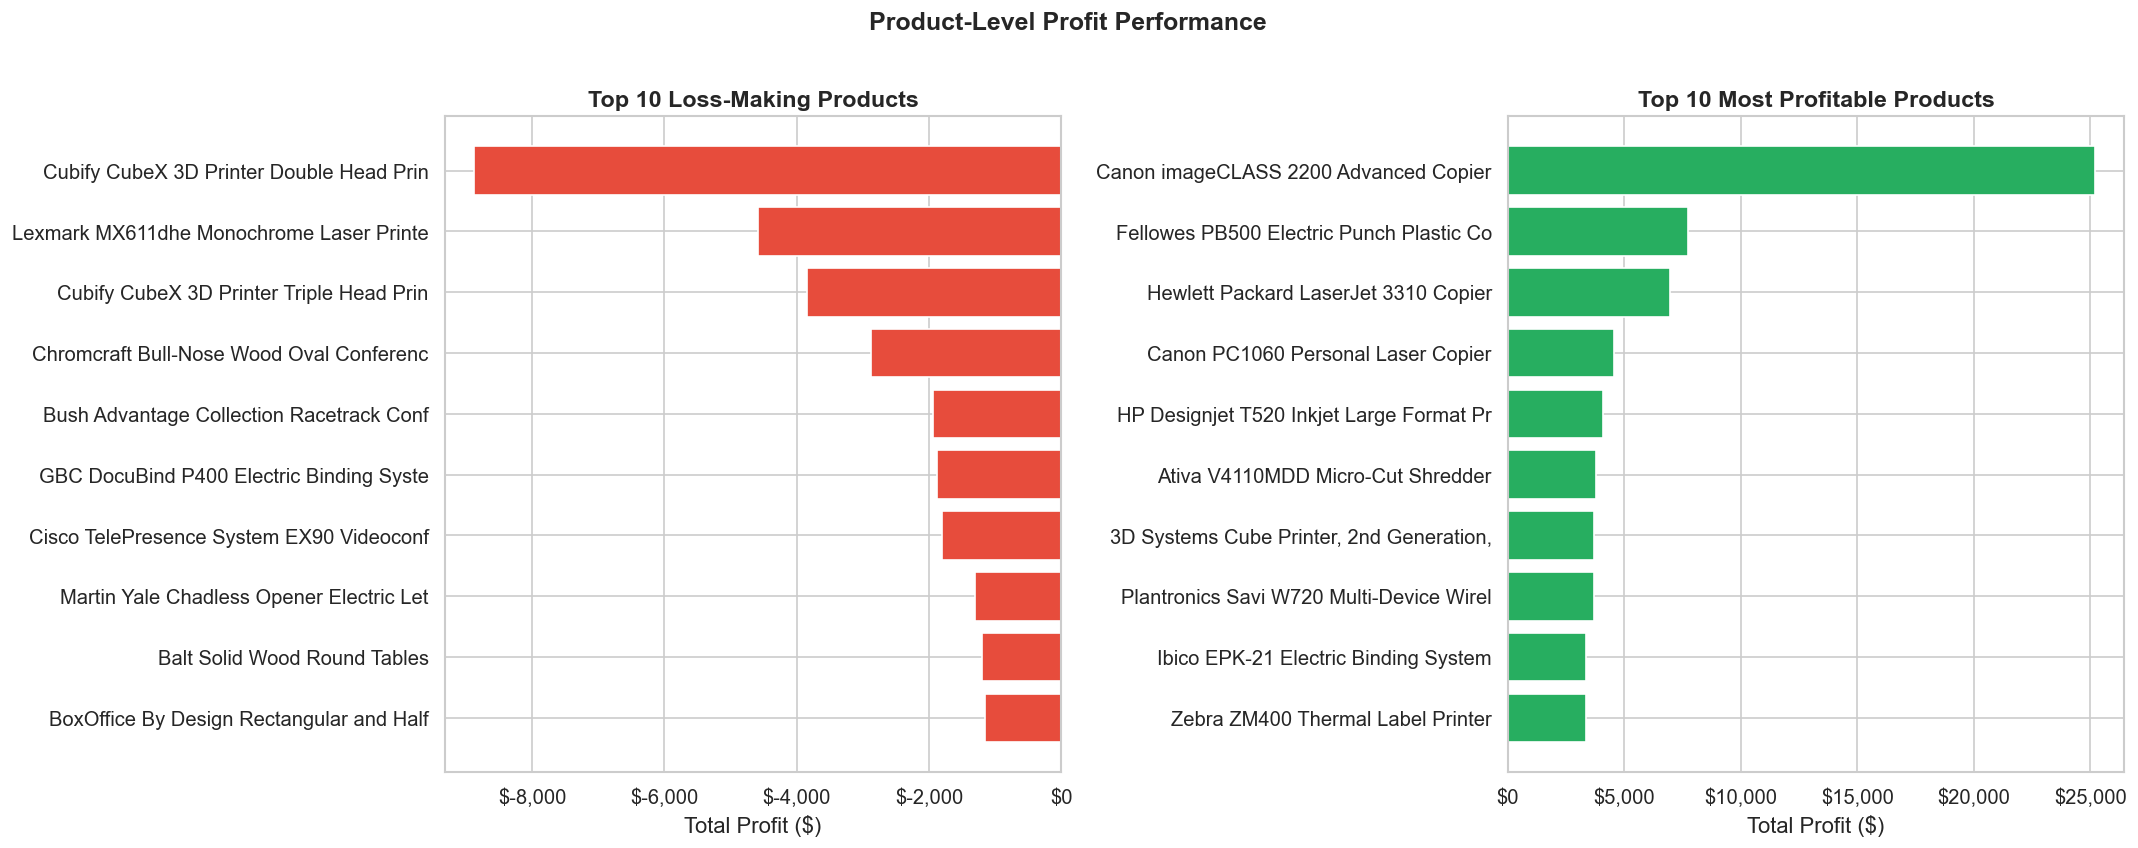

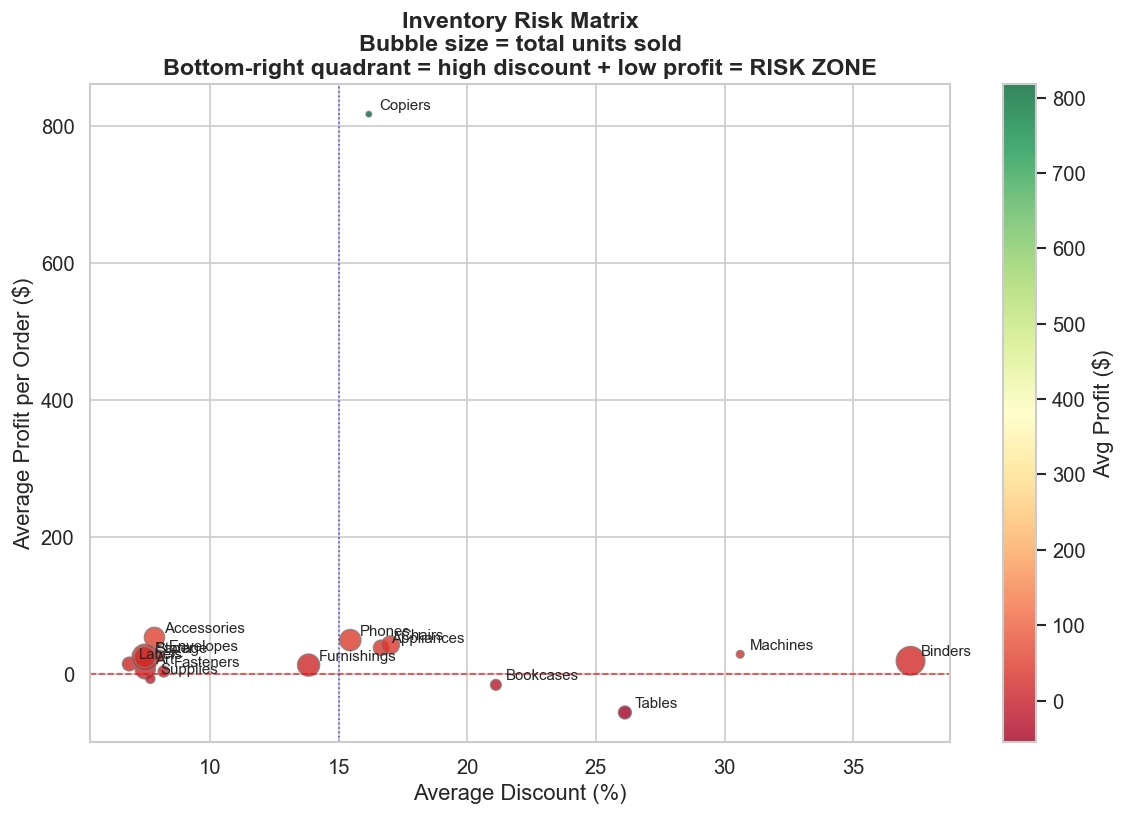

In [16]:

product_summary = df.groupby(['Product_Name', 'Category', 'Sub_Category']).agg(
    Units_Sold   = ('Quantity', 'sum'),
    Num_Txns     = ('Order_ID', 'count'),
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Avg_Discount = ('Discount', 'mean')
).reset_index()
product_summary['Margin_Pct'] = (product_summary['Total_Profit'] /
                                  product_summary['Total_Sales'] * 100).round(2)

# Slow-movers: low units sold AND loss-making
slow_movers = product_summary[
    (product_summary['Units_Sold'] <= 5) &
    (product_summary['Total_Profit'] < 0)
].sort_values('Total_Profit').copy()

print(f"🚨 SLOW-MOVING & LOSS-MAKING PRODUCTS: {len(slow_movers)}")
print("─" * 80)
print(f"{'Product (truncated)':<35} {'Units':>6} {'Profit':>10} {'Disc%':>7}")
print("─" * 80)
for _, r in slow_movers.head(15).iterrows():
    name = r['Product_Name'][:34]
    print(f"{name:<35} {r['Units_Sold']:>6} "
          f"${r['Total_Profit']:>9,.0f} {r['Avg_Discount']*100:>6.0f}%")

# Top 10 best and worst products overall
top10    = product_summary.nlargest(10, 'Total_Profit')
bottom10 = product_summary.nsmallest(10, 'Total_Profit')

# ── 9B. CHARTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Top 10 loss-making products
axes[0].barh(
    bottom10['Product_Name'].str[:40].values[::-1],
    bottom10['Total_Profit'].values[::-1],
    color='#e74c3c', edgecolor='white'
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('Top 10 Loss-Making Products')
axes[0].set_xlabel('Total Profit ($)')

# Chart 2: Top 10 profitable products
axes[1].barh(
    top10['Product_Name'].str[:40].values[::-1],
    top10['Total_Profit'].values[::-1],
    color='#27ae60', edgecolor='white'
)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Top 10 Most Profitable Products')
axes[1].set_xlabel('Total Profit ($)')

plt.suptitle('Product-Level Profit Performance',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_06_products.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9C. Sub-category Inventory Risk Matrix ───────────────────
inv_matrix = df.groupby('Sub_Category').agg(
    Avg_Discount = ('Discount', 'mean'),
    Avg_Profit   = ('Profit',   'mean'),
    Total_Units  = ('Quantity', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    inv_matrix['Avg_Discount'] * 100,
    inv_matrix['Avg_Profit'],
    s = inv_matrix['Total_Units'] / 20,   # bubble size
    c = inv_matrix['Avg_Profit'],
    cmap='RdYlGn', alpha=0.8,
    edgecolors='grey', linewidth=0.8
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(inv_matrix['Avg_Discount'].mean() * 100,
           color='blue', linestyle=':', linewidth=1, alpha=0.6)

for _, r in inv_matrix.iterrows():
    ax.annotate(r['Sub_Category'],
                (r['Avg_Discount']*100, r['Avg_Profit']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel('Average Discount (%)')
ax.set_ylabel('Average Profit per Order ($)')
ax.set_title('Inventory Risk Matrix\nBubble size = total units sold\n'
             'Bottom-right quadrant = high discount + low profit = RISK ZONE')
plt.colorbar(scatter, label='Avg Profit ($)')
plt.tight_layout()
plt.savefig('chart_07_inventory_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:

print("=" * 60)
print("       RETAIL ANALYSIS — STRATEGIC INSIGHTS")
print("=" * 60)

total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"""
📊 OVERALL PERFORMANCE (2014–2017)
   Total Revenue : ${total_sales:>12,.0f}
   Total Profit  : ${total_profit:>12,.0f}
   Overall Margin: {total_profit/total_sales*100:.2f}%

🔴 PROFIT DRAINS (Action Required)
   • Tables sub-category: net loss of $17,725 across all years
   • Bookcases: net loss of $3,472
   • Heavy discounting (30%+) makes 80–90% of orders unprofitable
   • Central region has lowest profit margin (~7.9%)
   • Texas and Ohio are the two biggest loss-making states

🟢 PROFIT DRIVERS (Double Down)
   • Copiers: highest total profit, strong margin (~32%)
   • Paper: excellent margin (~43%), high volume
   • West region: highest profit ($108K) and best margin
   • Technology category: most resilient across all regions

📅 SEASONAL INSIGHTS
   • Q4 (Oct–Dec) is the strongest quarter every year
   • November is consistently the highest sales month
   • Q1 (Jan–Mar) is the weakest — plan promotions here
   • Technology spikes heavily in Q4; plan inventory accordingly

⚠️  DISCOUNT STRATEGY FIXES
   • 0% discount orders average $65+ profit per order
   • 30%+ discount orders average -$40 loss per order
   • Cap Furniture discounts at 10% maximum
   • Never discount Tables — already loss-making at 0% discount

📦 INVENTORY RECOMMENDATIONS
   • Phase out: Cubify CubeX 3D Printer (worst single product)
   • Reduce stock of: GBC binding machines, Lexmark printers
   • Fast-movers to stock up for Q4: Phones, Copiers, Paper
""")

# ── EXPORT ENRICHED CSV FOR TABLEAU ─────────────────────────
export_df = df.copy()
export_df.to_csv('superstore_enriched.csv', index=False)

print("✅ EXPORTED: superstore_enriched.csv")
print(f"   Rows: {len(export_df):,}  |  Columns: {len(export_df.columns)}")
print("\n   New columns available in Tableau:")
added = ['Profit_Margin', 'Profit_Margin_Pct', 'Lead_Time_Days',
         'Inventory_Score', 'Year', 'Month_Num', 'Month_Name',
         'Quarter', 'Quarter_Label', 'Year_Month',
         'Discount_Bucket', 'Revenue_Per_Unit']
for c in added:
    print(f"   ✔ {c}")

print("\n📁 CHARTS SAVED:")
charts = [
    'chart_01_subcategory_profit.png',
    'chart_02_correlation.png',
    'chart_03_discount_impact.png',
    'chart_04_seasonal.png',
    'chart_05_regional.png',
    'chart_06_products.png',
    'chart_07_inventory_risk_matrix.png'
]
for c in charts:
    print(f"   ✔ {c}")

       RETAIL ANALYSIS — STRATEGIC INSIGHTS

📊 OVERALL PERFORMANCE (2014–2017)
   Total Revenue : $   2,297,201
   Total Profit  : $     286,397
   Overall Margin: 12.47%

🔴 PROFIT DRAINS (Action Required)
   • Tables sub-category: net loss of $17,725 across all years
   • Bookcases: net loss of $3,472
   • Heavy discounting (30%+) makes 80–90% of orders unprofitable
   • Central region has lowest profit margin (~7.9%)
   • Texas and Ohio are the two biggest loss-making states

🟢 PROFIT DRIVERS (Double Down)
   • Copiers: highest total profit, strong margin (~32%)
   • Paper: excellent margin (~43%), high volume
   • West region: highest profit ($108K) and best margin
   • Technology category: most resilient across all regions

📅 SEASONAL INSIGHTS
   • Q4 (Oct–Dec) is the strongest quarter every year
   • November is consistently the highest sales month
   • Q1 (Jan–Mar) is the weakest — plan promotions here
   • Technology spikes heavily in Q4; plan inventory accordingly

⚠️  DISCOUNT